# ASCON sub-key recovery attacking single output bit

## Configuration

In [15]:
#!/usr/bin/env python3
import sys
sys.path.append( '../../../sca_python' )
from analyzer.attack.ascon.xheep_ascon_cpa.ascon_first_round import ascon_first_round
from analyzer.attack.ascon.xheep_ascon_cpa.ascon_leakage_model import ascon_leakage_model
from analyzer.attack.ascon.xheep_ascon_cpa.ascon_cpa import ascon_cpa

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time
import logging

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s - %(levelname)s - %(message)s",
                    force=True)


In [16]:
key = "000102030405060708090A0B0C0D0E0F"
IV = "00001000808C0001" # Computed from the ASCON 128A parameters
IV = int(IV, 16)

# Number of traces
N = 10000
# Supported S-box types:
# lut_ascon, lut_bilgin, lut_allouzi, lut_lu_4, lut_lu_5, lut_lu_6, lut_lu_7
sbox_type = "lut_ascon"

traces_file = r"/traceset/ascon_sw/ascon_opt32_" + sbox_type + "_" + str(N//1000) + "k.h5"

## CPA attack on output state register

### CPA steps 
- Select which state register to target (S0 or S1) and pick which bit index to attack.
- For each trace, it's reconstructed the intermediate bit value (leakage model) from the nonce, IV and the selected register/bit using the ASCON selection function.
- Perform CPA: correlate the measured traces with the predicted leakage for each candidate sub-key and find which candidate yields the highest correlation.

The winning candidate gives the recovered sub-key bits by inverting the selection function (i.e., reconstructing the small sub-key that produced the predicted leakage).

**note** : the CPA attack is repeated with an incremental number of traces, in order to see how the distance between the correlation value of the correct key guess and the others increases with the number of traces.

_example :_ attacking bit 0 of output state register S[0] 
![ASCON selection function](media/ASCON_selection_function.png)

In [17]:
debug = False   # Set to True to enable debug prints

In [18]:
state_register_index = 0 # 0 or 1
shift_amount = [19, 28] if state_register_index == 0 else [61, 39]
bit_index = 49

# Reverse the key bytes to match X-HEEP's endianness
key_bytes = [key[i:i+2] for i in range(0,len(key), 2)]
key_reversed = ''.join(key_bytes[::-1])
key = int(key_reversed, 16)
logging.info("ASCON configuration\n - S-box type: %s\n - key: %s\n - IV: %016X", sbox_type, key, IV)
logging.info("Attacking bit %d of ASCON first round output register S%d with %d traces", bit_index, state_register_index, N)

2025-11-10 16:03:13,498 - INFO - ASCON configuration
 - S-box type: lut_ascon
 - key: 20011376718272490338853433276725592320
 - IV: 00001000808C0001
2025-11-10 16:03:13,499 - INFO - Attacking bit 49 of ASCON first round output register S0 with 10000 traces


In [19]:
corr_vs_traces = []
key_rank_vs_traces = []
state_register_index = 0
resolution = 50
k0 = key & 0xFFFFFFFFFFFFFFFF
tic = time.perf_counter()

# DEBUG
key_0 = key & 0xFFFFFFFFFFFFFFFF
key_0_j     = (key_0 >> (bit_index % 64)) & 1
key_0_j19   = (key_0 >> ((bit_index + 19) % 64)) & 1
key_0_j28   = (key_0 >> ((bit_index + 28) % 64)) & 1
expected_subkey = (key_0_j << 2) | (key_0_j19 << 1) | (key_0_j28 << 0)
try:
    with h5py.File(traces_file, 'r') as f_read_traces:
        traces = f_read_traces['traces'][:N]
        nonces = f_read_traces['nonces'][:N]
        print(f"Attacking bit index: {bit_index} of output state register: S[{state_register_index}]")
        print(f"Recovering key bits: k[{bit_index % 64}], k[{(bit_index + 19) % 64}], k[{(bit_index + 28) % 64}]")
        print(f"Number of traces: {len(traces)}, each composed of nr. samples: {len(traces[0])}")
        
        for count in range(1, (traces.shape[0] // resolution) + 1):
            partial_traces = traces[:(count*resolution)]
            partial_nonces = nonces[:(count*resolution)]
            # Build the leakage model matrix for all the nonces
            H_matrix = np.empty((len(partial_nonces), 8), dtype=np.uint8)
            R_matrix = np.empty((8, partial_traces.shape[1]), dtype=np.float64)
            for n in range(len(partial_nonces)):
                nonce_MSB = partial_nonces[n][1]
                nonce_LSB = partial_nonces[n][0]
                leakage_model_i = ascon_leakage_model(IV, nonce_MSB, nonce_LSB, state_register_index, bit_index, sbox_type, k0)
                H_matrix[n] = leakage_model_i
            # CPA attack
            R_matrix = ascon_cpa(partial_traces, H_matrix)
            # Find the time sample with the maximum correlation value
            corr_vs_keyguess = np.max(np.abs(R_matrix), axis=1) # shape (8,). Max value for each column (key guess) is returned
            if debug: print("Number of traces processed: ", len(partial_traces))
            for j in range(corr_vs_keyguess.shape[0]):
                max_corr_value = corr_vs_keyguess[j]
                if debug: print(f"Key guess {j}: {max_corr_value:.4f}")

            # Find the key guess with the maximum correlation value
            best_key_guess = np.argmax(corr_vs_keyguess)
            if debug: print(f"Key guess with maximum correlation value: {best_key_guess}")
            if debug: print(f"Expected key bits: ({key_0_j}, {key_0_j19}, {key_0_j28}), got: ({(best_key_guess >> 2) & 1}, {(best_key_guess >> 1) & 1}, {(best_key_guess >> 0) & 1})")

            # Store the correlation values for all the key guesses
            corr_vs_traces.append(corr_vs_keyguess)
            # Store the key rank of the correct key
            asc_idx = np.argsort(corr_vs_keyguess)[::-1]  # sort list from highest to lowest correlation values
            rank = int(np.where(asc_idx == expected_subkey)[0][0])
            key_rank_vs_traces.append(rank)

        toc = time.perf_counter()
        print(f"\nCPA attack completed in {(toc - tic)/60:.2f} minutes.\n")
except FileNotFoundError:
    print(f"ERROR: Traces file {traces_file} not found.")



Attacking bit index: 49 of output state register: S[0]
Recovering key bits: k[49], k[4], k[13]
Number of traces: 10000, each composed of nr. samples: 1125

CPA attack completed in 4.37 minutes.



## Plot of _Correlation vs Traces_

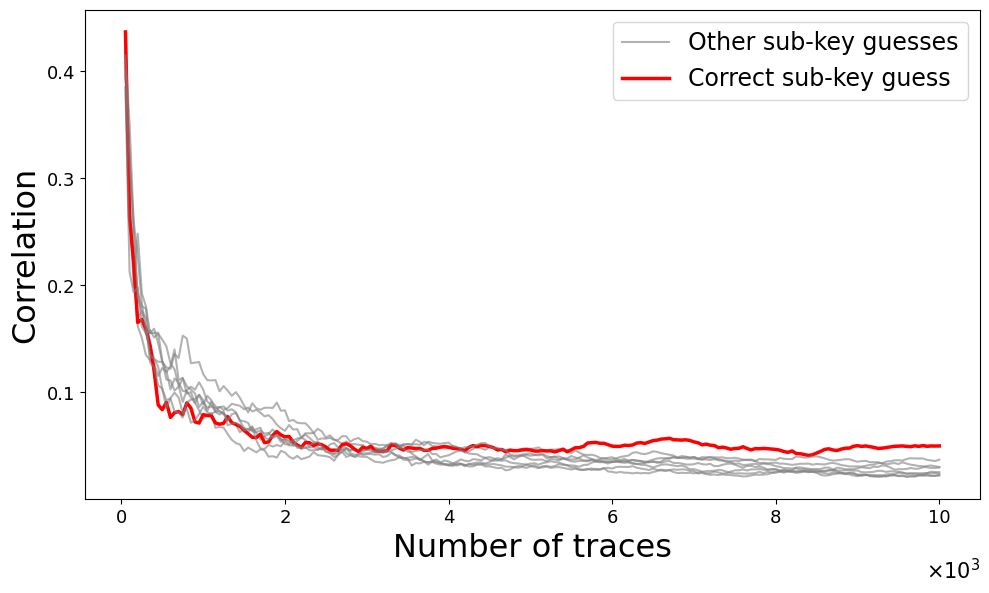

In [20]:
# Correlation vs traces plot
corr_vs_traces = np.array(corr_vs_traces)  # shape (steps, 8)
x = np.arange(1, len(corr_vs_traces) + 1) * resolution

fig, ax = plt.subplots(figsize=(10, 6))
first_other = True
for key_idx in range(8):
    if key_idx == expected_subkey:
        ax.plot(x, corr_vs_traces[:, key_idx],
                color='red',
                label=f"Correct sub-key guess",
                linewidth=2.5)
    else:
        lbl = "Other sub-key guesses" if first_other else "_nolegend_"
        ax.plot(x, corr_vs_traces[:, key_idx],
                alpha=0.6, color='gray', label=lbl)
        first_other = False

# set x ticks every 2000 traces and show them divided by 1000 (0,2,4,6,8,10)
max_x = int(np.max(x))
ticks = np.arange(0, max_x + 1, 2000)
ax.set_xticks(ticks)
ax.set_xticklabels((ticks / 1000).astype(int))

# main x label, then place "x10^3" at the end of the axis
ax.set_xlabel("Number of traces", fontsize=23)
ax.text(1.0, -0.12, r'$\times 10^{3}$',
        transform=ax.transAxes, ha='right', va='top', fontsize=15)
ax.set_ylabel("Correlation", fontsize=23)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.grid(False)
ax.legend(fontsize=17)
plt.tight_layout()

corr_fname = f"graphs/correlation_bit{bit_index}_sbox_{sbox_type}.pdf"
plt.savefig(corr_fname, format='pdf')
plt.show()
plt.close()

## Key rank vs Number of traces for the targetted sub-key

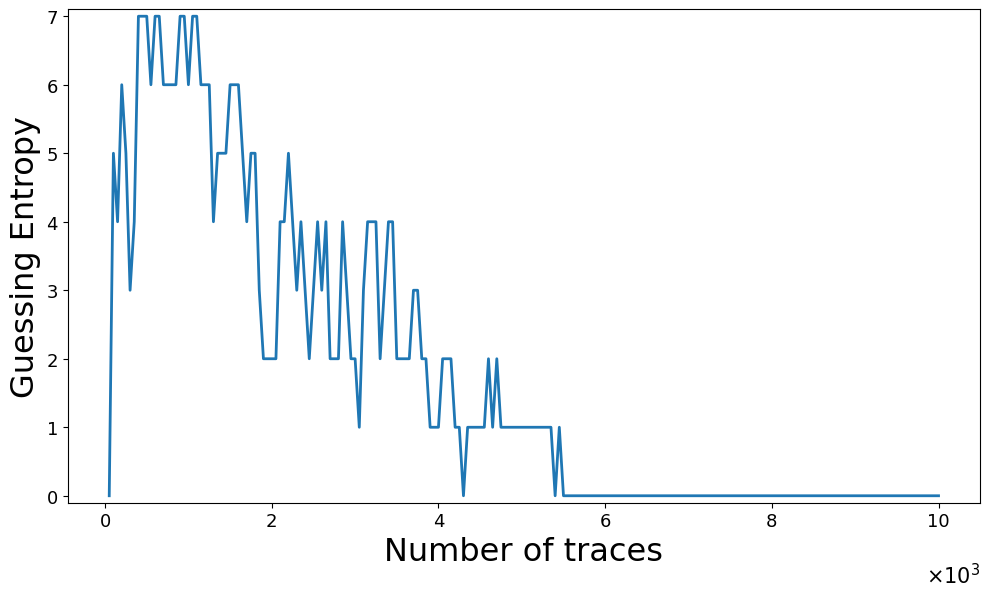

In [21]:
# Key rank / Guessing Entropy plot
key_rank_vs_traces = np.array(key_rank_vs_traces)
x = np.arange(1, len(key_rank_vs_traces) + 1) * resolution
ylims = (-0.1, 7.1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, key_rank_vs_traces, linewidth=2)

# set x ticks every 2000 traces and show them divided by 1000 (0,2,4,6,8,10)
max_x = int(np.max(x))
ticks = np.arange(0, max_x + 1, 2000)
ax.set_xticks(ticks)
ax.set_xticklabels((ticks / 1000).astype(int))

# same x label with ×10^3 rendered as mathtext at the axis end
ax.set_xlabel("Number of traces", fontsize=23)
ax.set_ylabel("Guessing Entropy", fontsize=23)
ax.text(1.0, -0.12, r'$\times 10^{3}$',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=15, clip_on=False)

ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.grid(False)
ax.set_ylim(ylims)

# ensure space for the annotation
fig.subplots_adjust(bottom=0.18, right=0.98)
plt.tight_layout()
rank_fname = f"graphs/keyrank_bit{bit_index}_sbox_{sbox_type}.pdf"
plt.savefig(rank_fname, format='pdf', bbox_inches='tight')
plt.show()
plt.close()